# Risk Analysis Tutorials: Week 6

Welcome to the Week 6 tutorial! 👋  

#### ✅ How to use this notebook

1. To save your own progress: Go to **File → Save a copy in Drive** (recommended)
2. The cell below will automatically **download all required data** from the course repository.  
3. You can run cells one by one using the play button on the top left of the cell or `Shift + Enter`.

**⚠️ Note: All work done here is temporary unless you save your own copy. Each time you reopen the notebook, Colab starts a new session.**

In [8]:
# Execute this cell. Do not modify it! It makes the notebook executable with Google Colab. If you are not using Colab, it will simply print a message.
!pip install matplotlib
!pip install numpy
!pip install scipy

# Task 1: Consulting Projects

In [9]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# Option 1: compute probability via Exponential distributions
N = 30000
counter = np.zeros(N)
E = stats.expon(scale=1)
for n in range(N):
    t = 0
    while True:
        t += E.rvs(size=1)
        if t < 3:
            counter[n] += 1
        else:
            break
print((counter < 3).sum() / N)

0.42083333333333334


In [11]:
# Option 2: compute probability via Poisson distribution
counter = np.zeros(N)
P = stats.poisson(3)
for n in range(N):
    counter[n] = P.rvs(size=1)
print((counter < 3).sum() / N)

0.4288666666666667


/var/folders/52/mwy83rjx3hxgk474svm849sh0000gn/T/ipykernel_92471/2403887647.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  counter[n] = P.rvs(size=1)


# Task 2: Insurance

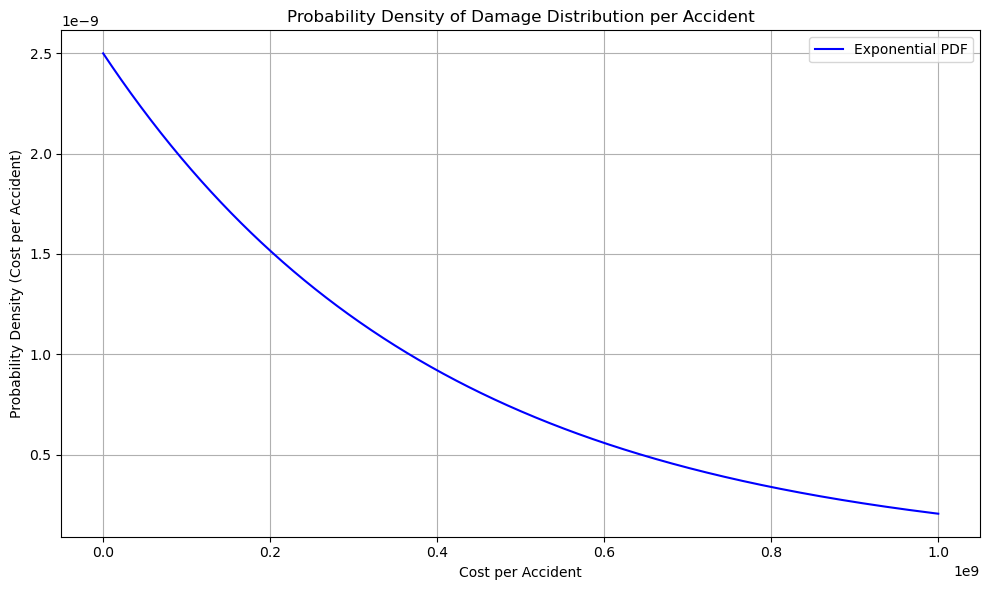

In [17]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

accident_rate = 2
time_interval = 1 #[year]

mu = accident_rate * time_interval

accident_distribution = stats.poisson(mu)

mean_exp = 400 * 10**6

damage_distribution = stats.expon(1/mean_exp)

x = np.linspace(0, 100, 100)


# Mean
mean_exp = 400 * 10**6

# Exponential Distribution with λ = 1/mean
damage_distribution_given_accident = stats.expon(scale=mean_exp)

# x-values (e.g., 0 to 1 billion in reasonable steps)
x = np.linspace(0, 1e9, 1000)

# Calculate PDF and CDF
pdf = damage_distribution_given_accident.pdf(x)
cdf = damage_distribution_given_accident.cdf(x)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, pdf, label='Exponential PDF', color='blue')
plt.xlabel('Cost per Accident')
plt.ylabel('Probability Density (Cost per Accident)')
plt.title('Probability Density of Damage Distribution per Accident')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# compute probability via accident sampling from Poisson and cost sampling from Exponential
lambda_acc = 2
D = stats.poisson(lambda_acc)

mean_cost = 400 * 10**6
lambda_cost = 1 / mean_exp
C = stats.expon(scale=1/lambda_cost)

N = 100000
counter = np.zeros(N)
for n in range(N):
    d = D.rvs(size=1).item()
    if d > 0:
        c = C.rvs(size=d)
        counter[n] = (c > 1e9).any()
    else:
        counter[n] = 0

print(counter.mean())


0.15135


# Task 3 Reliability of Redundant System

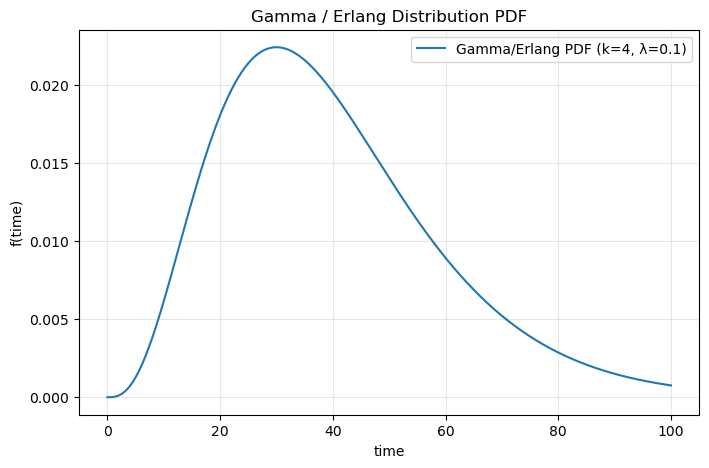

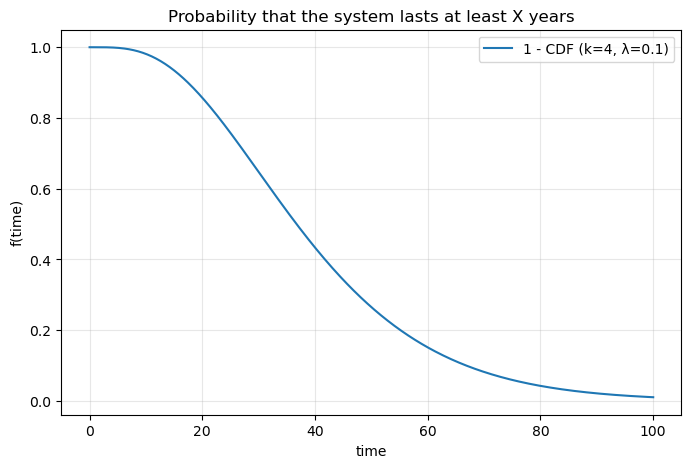

In [14]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
# Parameter
k = 4        # We want to know the time until the 4th failure
lam = 0.1    # 1/10 
theta = 1/lam  

gamma_dist = stats.gamma(a=k, scale=theta)

x = np.linspace(0, 30, 100)

# Values for plotting
x = np.linspace(0, 100, 500)
pdf_vals = gamma_dist.pdf(x)
cdf_vals = gamma_dist.cdf(x)

# Plot
plt.figure(figsize=(8,5))
plt.plot(x, pdf_vals, label=f"Gamma/Erlang PDF (k={k}, λ={lam})")
plt.title("Gamma / Erlang Distribution PDF")
plt.xlabel("time")
plt.ylabel("f(time)")
plt.grid(alpha=0.3)
plt.legend()
plt.figure(figsize=(8,5))

plt.plot(x, 1 - cdf_vals, label=f"1 - CDF (k={k}, λ={lam})")
plt.title(f"Probability that the system lasts at least X years")
plt.xlabel("time")
plt.ylabel("f(time)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# Task 4

a) p_no_failure=np.float64(0.3678961432513663)
b) poisson equation used for the calculation


/var/folders/52/mwy83rjx3hxgk474svm849sh0000gn/T/ipykernel_92471/3404749149.py:4: RuntimeWarning: divide by zero encountered in divide
  return 1/x * np.exp(-x/10)
/var/folders/52/mwy83rjx3hxgk474svm849sh0000gn/T/ipykernel_92471/3404749149.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


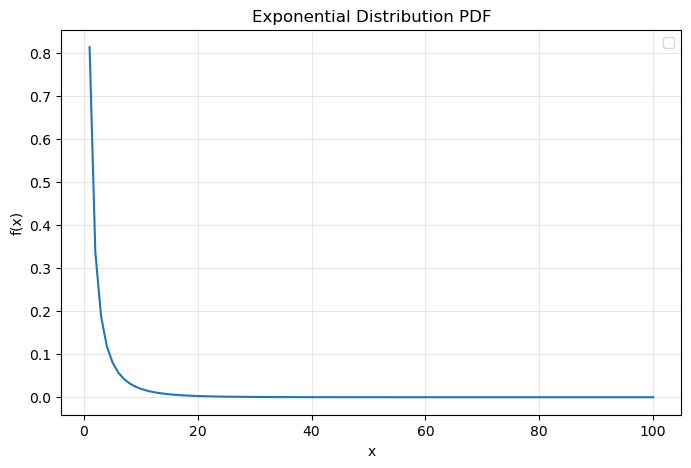

In [15]:
import math

def lmbda(x):
  return 1/x * np.exp(-x/10)

def mu(x):
  return 1 - np.exp(-x/10)

def poisson(x, f):
  return mu(x)**f/math.factorial(f) * np.exp(-mu(x))

p_no_failure = poisson(x=100, f=0)

print(f"a) {p_no_failure=}")
print(f"b) poisson equation used for the calculation")

def exponential(x):
  return lmbda(x) * np.exp(-mu(x))

# Plot

x = np.linspace(0,100,100)
pdf_vals = exponential(x=x)
plt.figure(figsize=(8,5))
plt.plot(x, pdf_vals)
plt.title("Exponential Distribution PDF")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

